# 🔍 Embedding Model Evaluation for FinanceRAG

This notebook evaluates different embedding models to find the best one for financial document retrieval.

## Objectives:
1. Test multiple embedding models on sampled data
2. Compare NDCG@10 scores across datasets
3. Analyze model performance characteristics
4. Recommend the best model for production

## Sampling Strategy (similar to chunking evaluation):
- **Smart corpus sampling**: Include all relevant docs + random non-relevant docs
- **Query sampling**: 30-50 queries per dataset
- **Reproducible**: Fixed random seed for consistency

## 📦 Setup and Imports

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from typing import List, Dict, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
import time
import gc
import torch

warnings.filterwarnings('ignore')

# Embedding libraries
from sentence_transformers import SentenceTransformer

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("   Running on CPU")
    device = 'cpu'

✅ Libraries imported successfully!
🖥️ CUDA available: True
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## ⚙️ Configuration

In [ ]:
# Load configuration from config.py
from config import (
    DATA_DIR, OUTPUT_DIR, DATASETS,
    EMBEDDING_MODELS, SAMPLE_QUERIES_PER_DATASET,
    MAX_CORPUS_SAMPLE_SIZE, USE_SMART_SAMPLING,
    MAX_TEXT_LENGTH, BATCH_SIZE, LOCAL_MODELS_DIR,
    get_embedding_models, print_config
)

# Create output directory
OUTPUT_DIR.mkdir(exist_ok=True)

# Get all embedding models (including local finetuned ones)
EMBEDDING_MODELS = get_embedding_models()

# Print configuration summary
print_config()

# Check for local models
if LOCAL_MODELS_DIR.exists():
    for model_dir in LOCAL_MODELS_DIR.iterdir():
        if model_dir.is_dir() and 'financerag' in model_dir.name.lower():
            print(f"📁 Found local model: {model_dir.name}")

📁 Found local model: bge-base-financerag-finetuned
📁 Found local model: bge-large-financerag-finetuned
📁 Found local model: bge-large-financerag-finetuned-v2

📊 Configuration:
   Datasets: 7
   Embedding models: 14

⚡ Speed optimizations:
   Queries per dataset: 30
   Max corpus sample: 500
   Smart sampling: True
   Max text length: 512

🤖 Models to evaluate:
   [1] MiniLM-L6: Fast, lightweight (22M params)
   [2] MPNet-base: Strong general purpose (110M params)
   [3] BGE-small: Small BGE (33M params)
   [4] BGE-base: Base BGE (110M params)
   [5] BGE-large: Large BGE (335M params)
   [6] E5-small: Small E5 (33M params)
   [7] E5-base: Base E5 (110M params)
   [8] E5-large: Large E5 (335M params)
   [9] GTE-small: Small GTE (33M params)
   [10] GTE-base: Base GTE (110M params)
   [11] GTE-large: Large GTE (335M params)
   [12] bge-base-financerag-finetuned: Local finetuned model
   [13] bge-large-financerag-finetuned: Local finetuned model
   [14] bge-large-financerag-finetuned-v2: L

## 📚 Data Loading Functions

In [ ]:
# Import shared utilities
from utils import (
    load_jsonl,
    load_dataset_for_evaluation as load_dataset,
    QRELS_MAPPING
)

print("✅ Data loading functions imported from utils.py")

✅ Data loading functions defined


## 🎯 Smart Sampling Functions

In [ ]:
# Import sampling functions from shared utils
from utils import sample_queries, smart_sample_corpus

print("✅ Sampling functions imported from utils.py")

✅ Sampling functions defined


## 📊 NDCG Evaluation Functions

In [ ]:
# Import evaluation metrics from shared utils
from utils import compute_ndcg, compute_recall_at_k, compute_mrr

print("✅ Evaluation metrics imported from utils.py: compute_ndcg, compute_recall_at_k, compute_mrr")

✅ Evaluation metrics defined: NDCG@k, Recall@k, MRR


## 🔍 Embedding Model Evaluation Pipeline

In [6]:
def prepare_text_for_embedding(text: str, model_name: str, max_length: int = 512) -> str:
    """
    Prepare text for embedding with model-specific formatting.
    
    Some models (E5, BGE) require special prefixes for queries/documents.
    """
    # Truncate
    text = text[:max_length * 4]  # Rough char limit
    
    return text


def prepare_query_for_embedding(query: str, model_name: str) -> str:
    """
    Prepare query for embedding with model-specific formatting.
    
    E5 models: prefix with "query: "
    BGE models: can use instruction prefix
    """
    model_lower = model_name.lower()
    
    # E5 models need "query: " prefix
    if 'e5' in model_lower:
        return f"query: {query}"
    
    # BGE models can use instruction
    if 'bge' in model_lower:
        # For retrieval, BGE can use a simple prefix
        return query  # or add instruction if needed
    
    return query


def prepare_document_for_embedding(doc_text: str, model_name: str) -> str:
    """
    Prepare document for embedding with model-specific formatting.
    
    E5 models: prefix with "passage: "
    """
    model_lower = model_name.lower()
    
    # E5 models need "passage: " prefix for documents
    if 'e5' in model_lower:
        return f"passage: {doc_text}"
    
    return doc_text


def evaluate_embedding_model(
    model_name: str,
    display_name: str,
    dataset_name: str,
    corpus: List[Dict],
    queries: List[Dict],
    qrels: Dict,
    max_corpus_size: int = 500,
    n_queries: int = 30
) -> Dict:
    """
    Evaluate a single embedding model on a dataset.
    
    Args:
        model_name: HuggingFace model name or local path
        display_name: Display name for reporting
        dataset_name: Name of the dataset
        corpus: List of documents
        queries: List of queries
        qrels: Relevance judgments
        max_corpus_size: Maximum corpus size after sampling
        n_queries: Number of queries to sample
    
    Returns:
        Dictionary with evaluation results
    """
    start_time = time.time()
    
    try:
        # Sample queries
        queries_sample = sample_queries(queries, qrels, n_queries)
        if not queries_sample:
            return {
                'model': display_name,
                'dataset': dataset_name,
                'ndcg_10': 0.0,
                'recall_10': 0.0,
                'mrr': 0.0,
                'error': 'No valid queries'
            }
        
        # Smart sample corpus
        corpus_sample = smart_sample_corpus(corpus, qrels, queries_sample, max_corpus_size)
        
        # Load model
        model = SentenceTransformer(model_name, device=device)
        
        # Prepare corpus texts
        corpus_texts = []
        corpus_ids = []
        for doc in corpus_sample:
            text = doc.get('text', '')
            title = doc.get('title', '')
            full_text = f"{title}\n{text}" if title else text
            prepared_text = prepare_document_for_embedding(full_text[:MAX_TEXT_LENGTH * 4], model_name)
            corpus_texts.append(prepared_text)
            corpus_ids.append(doc['_id'])
        
        # Encode corpus
        corpus_embeddings = model.encode(
            corpus_texts,
            show_progress_bar=False,
            batch_size=BATCH_SIZE,
            normalize_embeddings=True
        )
        
        # Prepare and encode queries
        query_texts = [prepare_query_for_embedding(q['text'], model_name) for q in queries_sample]
        query_embeddings = model.encode(
            query_texts,
            show_progress_bar=False,
            batch_size=BATCH_SIZE,
            normalize_embeddings=True
        )
        
        # Evaluate each query
        ndcg_scores = []
        recall_scores = []
        mrr_scores = []
        
        for i, query_obj in enumerate(queries_sample):
            query_id = query_obj['_id']
            
            if query_id not in qrels:
                continue
            
            # Compute similarities (dot product since normalized)
            similarities = np.dot(corpus_embeddings, query_embeddings[i])
            
            # Get top-k
            top_indices = np.argsort(similarities)[::-1][:100]  # Get top 100 for recall
            retrieved = [corpus_ids[idx] for idx in top_indices]
            
            # Compute metrics
            ndcg = compute_ndcg(retrieved, qrels[query_id], k=10)
            recall = compute_recall_at_k(retrieved, qrels[query_id], k=10)
            mrr = compute_mrr(retrieved, qrels[query_id])
            
            ndcg_scores.append(ndcg)
            recall_scores.append(recall)
            mrr_scores.append(mrr)
        
        # Clean up to free memory
        del model, corpus_embeddings, query_embeddings
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        elapsed_time = time.time() - start_time
        
        return {
            'model': display_name,
            'model_name': model_name,
            'dataset': dataset_name,
            'ndcg_10': np.mean(ndcg_scores) if ndcg_scores else 0.0,
            'ndcg_10_std': np.std(ndcg_scores) if ndcg_scores else 0.0,
            'recall_10': np.mean(recall_scores) if recall_scores else 0.0,
            'mrr': np.mean(mrr_scores) if mrr_scores else 0.0,
            'num_queries': len(ndcg_scores),
            'corpus_size': len(corpus_sample),
            'time_seconds': elapsed_time,
            'error': None
        }
        
    except Exception as e:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return {
            'model': display_name,
            'model_name': model_name,
            'dataset': dataset_name,
            'ndcg_10': 0.0,
            'recall_10': 0.0,
            'mrr': 0.0,
            'error': str(e)[:100]
        }


print("✅ Evaluation pipeline defined")

✅ Evaluation pipeline defined


## 🚀 Run Complete Evaluation

In [7]:
# Store all results
all_results = []

# Cache loaded datasets
dataset_cache = {}

# Track total time
total_start_time = time.time()

print("="*80)
print("🚀 STARTING EMBEDDING MODEL EVALUATION")
print("="*80)
print(f"📊 Datasets: {len(DATASETS)}")
print(f"🤖 Models: {len(EMBEDDING_MODELS)}")
print(f"📝 Total evaluations: {len(DATASETS) * len(EMBEDDING_MODELS)}")
print("="*80)

# Iterate over models first (to avoid reloading same model)
for model_idx, (model_name, display_name, description) in enumerate(EMBEDDING_MODELS, 1):
    print(f"\n{'='*80}")
    print(f"🤖 [{model_idx}/{len(EMBEDDING_MODELS)}] Loading: {display_name}")
    print(f"   {model_name}")
    print(f"   {description}")
    print("="*80)
    
    model_start_time = time.time()
    
    for dataset_idx, dataset_name in enumerate(DATASETS, 1):
        print(f"\n   📊 [{dataset_idx}/{len(DATASETS)}] Evaluating on: {dataset_name}")
        
        # Load dataset (cache if not already loaded)
        if dataset_name not in dataset_cache:
            print(f"      📂 Loading dataset...")
            corpus, queries, qrels = load_dataset(dataset_name)
            dataset_cache[dataset_name] = (corpus, queries, qrels)
            print(f"      ✅ Loaded: {len(corpus)} docs, {len(queries)} queries")
        else:
            corpus, queries, qrels = dataset_cache[dataset_name]
        
        # Evaluate
        result = evaluate_embedding_model(
            model_name=model_name,
            display_name=display_name,
            dataset_name=dataset_name,
            corpus=corpus,
            queries=queries,
            qrels=qrels,
            max_corpus_size=MAX_CORPUS_SAMPLE_SIZE,
            n_queries=SAMPLE_QUERIES_PER_DATASET
        )
        
        all_results.append(result)
        
        if result.get('error'):
            print(f"      ❌ Error: {result['error']}")
        else:
            print(f"      ✅ NDCG@10: {result['ndcg_10']:.4f} | Recall@10: {result['recall_10']:.4f} | MRR: {result['mrr']:.4f}")
            print(f"      ⏱️ Time: {result['time_seconds']:.1f}s")
    
    model_time = time.time() - model_start_time
    print(f"\n   ⏱️ Model total time: {model_time:.1f}s")

total_time = time.time() - total_start_time
print(f"\n{'='*80}")
print(f"✅ EVALUATION COMPLETE!")
print(f"⏱️ Total time: {total_time/60:.1f} minutes")
print(f"📊 Total evaluations: {len(all_results)}")
print("="*80)

🚀 STARTING EMBEDDING MODEL EVALUATION
📊 Datasets: 7
🤖 Models: 14
📝 Total evaluations: 98

🤖 [1/14] Loading: MiniLM-L6
   sentence-transformers/all-MiniLM-L6-v2
   Fast, lightweight (22M params)

   📊 [1/7] Evaluating on: convfinqa
      📂 Loading dataset...
      ✅ Loaded: 2066 docs, 421 queries
      ✅ NDCG@10: 0.3195 | Recall@10: 0.4667 | MRR: 0.2803
      ⏱️ Time: 10.0s

   📊 [2/7] Evaluating on: financebench
      📂 Loading dataset...
      ✅ Loaded: 180 docs, 150 queries
      ✅ NDCG@10: 0.7278 | Recall@10: 0.9833 | MRR: 0.6664
      ⏱️ Time: 4.6s

   📊 [3/7] Evaluating on: finder
      📂 Loading dataset...
      ✅ Loaded: 13867 docs, 216 queries
      ✅ NDCG@10: 0.6498 | Recall@10: 0.7389 | MRR: 0.6457
      ⏱️ Time: 5.5s

   📊 [4/7] Evaluating on: finqa
      📂 Loading dataset...
      ✅ Loaded: 2789 docs, 1147 queries
      ✅ NDCG@10: 0.3150 | Recall@10: 0.4333 | MRR: 0.2834
      ⏱️ Time: 6.2s

   📊 [5/7] Evaluating on: finqabench
      📂 Loading dataset...
      ✅ Loaded: 92 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

      ❌ Error: A configuration of type rag cannot be instantiated because both `question_encoder` and `generator` s

   📊 [5/7] Evaluating on: finqabench


No sentence-transformers model found with name ..\models\bge-large-financerag-finetuned-v2. Creating a new one with mean pooling.


      ❌ Error: A configuration of type rag cannot be instantiated because both `question_encoder` and `generator` s

   📊 [6/7] Evaluating on: multiheirtt


No sentence-transformers model found with name ..\models\bge-large-financerag-finetuned-v2. Creating a new one with mean pooling.


      ❌ Error: A configuration of type rag cannot be instantiated because both `question_encoder` and `generator` s

   📊 [7/7] Evaluating on: tatqa
      ❌ Error: A configuration of type rag cannot be instantiated because both `question_encoder` and `generator` s

   ⏱️ Model total time: 1.8s

✅ EVALUATION COMPLETE!
⏱️ Total time: 41.7 minutes
📊 Total evaluations: 98


## 📊 Results Analysis

In [8]:
# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Filter out errors
valid_results = results_df[results_df['error'].isna()].copy()

print(f"📊 Valid results: {len(valid_results)}/{len(results_df)}")
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Display all results
display_cols = ['model', 'dataset', 'ndcg_10', 'recall_10', 'mrr', 'time_seconds']
print(valid_results[display_cols].to_string(index=False))

📊 Valid results: 77/98

RESULTS SUMMARY
     model      dataset  ndcg_10  recall_10      mrr  time_seconds
 MiniLM-L6    convfinqa 0.319480   0.466667 0.280316     10.017880
 MiniLM-L6 financebench 0.727840   0.983333 0.666389      4.577666
 MiniLM-L6       finder 0.649802   0.738889 0.645706      5.471344
 MiniLM-L6        finqa 0.315044   0.433333 0.283427      6.209690
 MiniLM-L6   finqabench 0.845998   0.933333 0.819563      4.389309
 MiniLM-L6  multiheirtt 0.094056   0.109365 0.201780      6.232244
 MiniLM-L6        tatqa 0.389361   0.533333 0.356994      6.147934
MPNet-base    convfinqa 0.250306   0.400000 0.216919     28.186825
MPNet-base financebench 0.799490   0.966667 0.753030     11.218329
MPNet-base       finder 0.678863   0.800000 0.670235     17.037033
MPNet-base        finqa 0.296690   0.466667 0.256488     27.476815
MPNet-base   finqabench 0.879760   0.933333 0.864007      7.288146
MPNet-base  multiheirtt 0.127514   0.132381 0.283060     25.614229
MPNet-base        tatq

In [9]:
# Pivot table: Models vs Datasets
print("\n" + "="*80)
print("📊 NDCG@10 BY MODEL AND DATASET")
print("="*80)

pivot_ndcg = valid_results.pivot_table(
    index='model',
    columns='dataset',
    values='ndcg_10',
    aggfunc='mean'
)

# Add mean column
pivot_ndcg['MEAN'] = pivot_ndcg.mean(axis=1)

# Sort by mean
pivot_ndcg = pivot_ndcg.sort_values('MEAN', ascending=False)

# Format for display
print(pivot_ndcg.round(4).to_string())

print("\n" + "="*80)
print("🏆 BEST MODEL (by mean NDCG@10):")
best_model = pivot_ndcg['MEAN'].idxmax()
best_score = pivot_ndcg['MEAN'].max()
print(f"   {best_model}: {best_score:.4f}")
print("="*80)


📊 NDCG@10 BY MODEL AND DATASET
dataset     convfinqa  financebench  finder   finqa  finqabench  multiheirtt   tatqa    MEAN
model                                                                                       
E5-small       0.4155        0.7273  0.8089  0.3472      0.9050       0.2071  0.4478  0.5513
E5-large       0.3845        0.7844  0.8010  0.3579      0.8318       0.1384  0.5005  0.5427
GTE-large      0.3594        0.7824  0.8095  0.2746      0.9064       0.1550  0.4177  0.5293
E5-base        0.3852        0.7758  0.8096  0.2626      0.8661       0.1609  0.4410  0.5287
BGE-large      0.4137        0.7809  0.7630  0.2790      0.8439       0.1617  0.3985  0.5201
BGE-base       0.3351        0.7886  0.7515  0.2903      0.8862       0.1577  0.4180  0.5182
GTE-base       0.3164        0.7780  0.7875  0.3129      0.8860       0.1314  0.3988  0.5158
BGE-small      0.3173        0.7405  0.6930  0.2724      0.8837       0.1202  0.3731  0.4857
MPNet-base     0.2503        0.7995  0

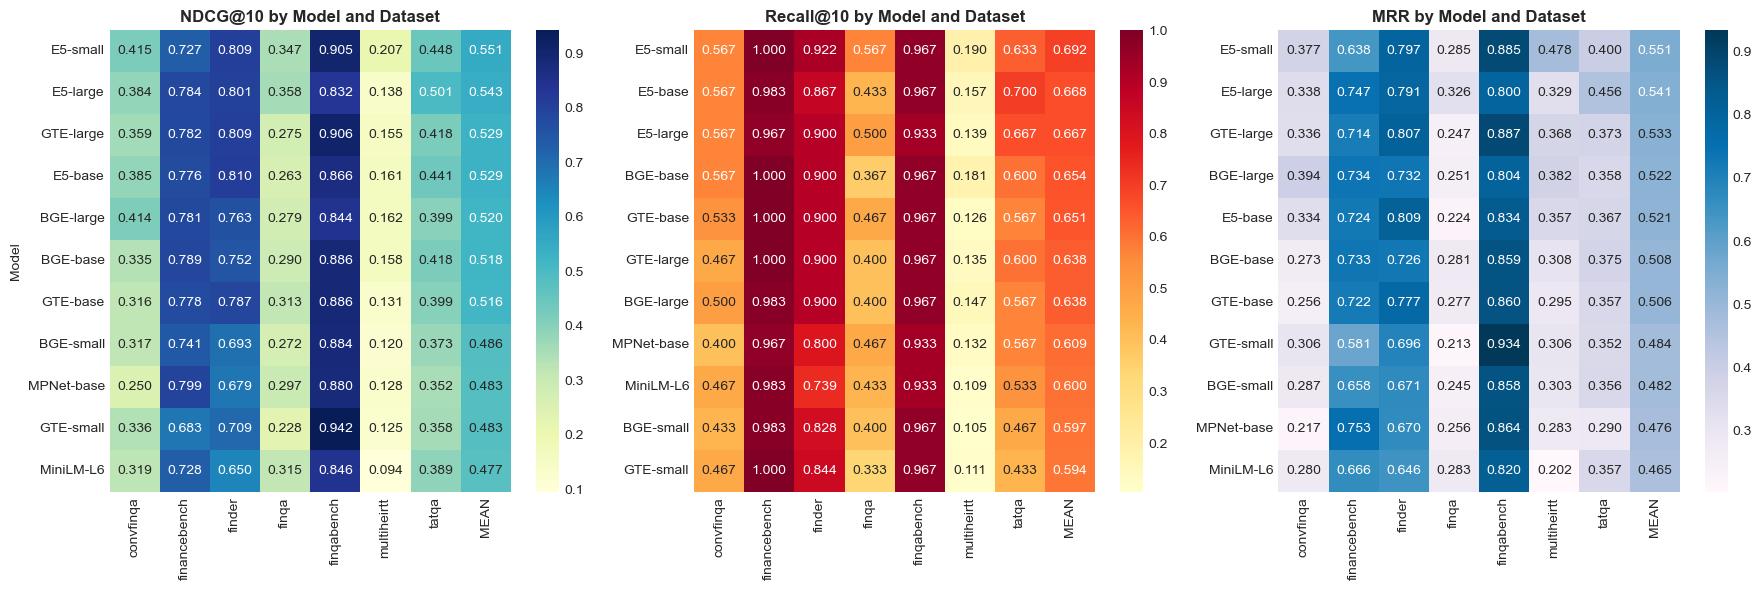


📁 Saved heatmap to: output_embedding_eval\embedding_model_comparison_heatmap.png


In [10]:
# Heatmap visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# NDCG@10 heatmap
pivot_ndcg_display = valid_results.pivot_table(
    index='model',
    columns='dataset',
    values='ndcg_10',
    aggfunc='mean'
)
pivot_ndcg_display['MEAN'] = pivot_ndcg_display.mean(axis=1)
pivot_ndcg_display = pivot_ndcg_display.sort_values('MEAN', ascending=False)

sns.heatmap(pivot_ndcg_display, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('NDCG@10 by Model and Dataset', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Model')

# Recall@10 heatmap
pivot_recall = valid_results.pivot_table(
    index='model',
    columns='dataset',
    values='recall_10',
    aggfunc='mean'
)
pivot_recall['MEAN'] = pivot_recall.mean(axis=1)
pivot_recall = pivot_recall.sort_values('MEAN', ascending=False)

sns.heatmap(pivot_recall, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Recall@10 by Model and Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# MRR heatmap
pivot_mrr = valid_results.pivot_table(
    index='model',
    columns='dataset',
    values='mrr',
    aggfunc='mean'
)
pivot_mrr['MEAN'] = pivot_mrr.mean(axis=1)
pivot_mrr = pivot_mrr.sort_values('MEAN', ascending=False)

sns.heatmap(pivot_mrr, annot=True, fmt='.3f', cmap='PuBu', ax=axes[2])
axes[2].set_title('MRR by Model and Dataset', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'embedding_model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📁 Saved heatmap to: {OUTPUT_DIR / 'embedding_model_comparison_heatmap.png'}")

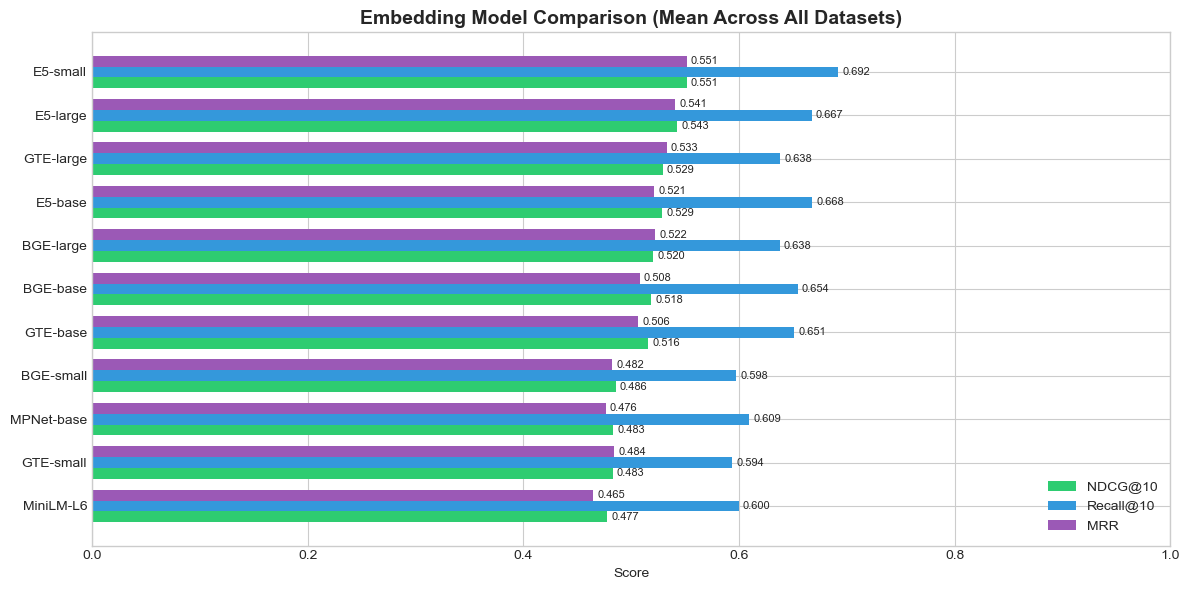


📁 Saved ranking chart to: output_embedding_eval\embedding_model_ranking.png


In [11]:
# Bar chart: Overall model ranking
fig, ax = plt.subplots(figsize=(12, 6))

# Compute mean scores per model
model_means = valid_results.groupby('model').agg({
    'ndcg_10': 'mean',
    'recall_10': 'mean',
    'mrr': 'mean'
}).round(4)

model_means = model_means.sort_values('ndcg_10', ascending=True)

# Create horizontal bar chart
y_pos = np.arange(len(model_means))
width = 0.25

bars1 = ax.barh(y_pos - width, model_means['ndcg_10'], width, label='NDCG@10', color='#2ecc71')
bars2 = ax.barh(y_pos, model_means['recall_10'], width, label='Recall@10', color='#3498db')
bars3 = ax.barh(y_pos + width, model_means['mrr'], width, label='MRR', color='#9b59b6')

ax.set_yticks(y_pos)
ax.set_yticklabels(model_means.index)
ax.set_xlabel('Score')
ax.set_title('Embedding Model Comparison (Mean Across All Datasets)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.3f}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3, 0),
                    textcoords="offset points",
                    ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'embedding_model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📁 Saved ranking chart to: {OUTPUT_DIR / 'embedding_model_ranking.png'}")

In [12]:
# Best model per dataset
print("\n" + "="*80)
print("🏆 BEST MODEL PER DATASET")
print("="*80)

best_per_dataset = valid_results.loc[
    valid_results.groupby('dataset')['ndcg_10'].idxmax()
][['dataset', 'model', 'ndcg_10', 'recall_10', 'mrr']]

print(best_per_dataset.to_string(index=False))

# Count wins per model
print("\n" + "="*80)
print("🥇 MODEL WINS (number of datasets where model is best)")
print("="*80)

wins = best_per_dataset['model'].value_counts()
for model, count in wins.items():
    datasets = best_per_dataset[best_per_dataset['model'] == model]['dataset'].tolist()
    print(f"   {model}: {count} wins ({', '.join(datasets)})")


🏆 BEST MODEL PER DATASET
     dataset      model  ndcg_10  recall_10      mrr
   convfinqa   E5-small 0.415495   0.566667 0.377326
financebench MPNet-base 0.799490   0.966667 0.753030
      finder    E5-base 0.809610   0.866667 0.808710
       finqa   E5-large 0.357943   0.500000 0.325996
  finqabench  GTE-small 0.942062   0.966667 0.933918
 multiheirtt   E5-small 0.207120   0.189921 0.477502
       tatqa   E5-large 0.500503   0.666667 0.455844

🥇 MODEL WINS (number of datasets where model is best)
   E5-small: 2 wins (convfinqa, multiheirtt)
   E5-large: 2 wins (finqa, tatqa)
   MPNet-base: 1 wins (financebench)
   E5-base: 1 wins (finder)
   GTE-small: 1 wins (finqabench)


## 💾 Save Results

In [13]:
# Save detailed results
results_df.to_csv(OUTPUT_DIR / 'embedding_model_evaluation_results.csv', index=False)
print(f"📁 Saved detailed results to: {OUTPUT_DIR / 'embedding_model_evaluation_results.csv'}")

# Save pivot tables
pivot_ndcg.to_csv(OUTPUT_DIR / 'embedding_model_ndcg_pivot.csv')
print(f"📁 Saved NDCG pivot to: {OUTPUT_DIR / 'embedding_model_ndcg_pivot.csv'}")

# Save best configurations
best_config = {
    'overall_best_model': best_model,
    'overall_best_score': float(best_score),
    'best_per_dataset': best_per_dataset.to_dict('records'),
    'model_means': model_means.to_dict('index')
}

with open(OUTPUT_DIR / 'best_embedding_model_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print(f"📁 Saved best config to: {OUTPUT_DIR / 'best_embedding_model_config.json'}")

print("\n" + "="*80)
print("✅ ALL RESULTS SAVED!")
print("="*80)

📁 Saved detailed results to: output_embedding_eval\embedding_model_evaluation_results.csv
📁 Saved NDCG pivot to: output_embedding_eval\embedding_model_ndcg_pivot.csv
📁 Saved best config to: output_embedding_eval\best_embedding_model_config.json

✅ ALL RESULTS SAVED!


## 📝 Summary and Recommendations

In [ ]:
print("\n" + "="*80)
print("📝 SUMMARY AND RECOMMENDATIONS")
print("="*80)

# Top 3 models
top_3_models = model_means.sort_values('ndcg_10', ascending=False).head(3)

print("\n🏆 TOP 3 EMBEDDING MODELS:")
print("="*40)
for i, (model, scores) in enumerate(top_3_models.iterrows(), 1):
    medal = ['🥇', '🥈', '🥉'][i-1]
    print(f"{medal} #{i}: {model}")
    print(f"      NDCG@10: {scores['ndcg_10']:.4f}")
    print(f"      Recall@10: {scores['recall_10']:.4f}")
    print(f"      MRR: {scores['mrr']:.4f}")
    print()

print("\n💡 RECOMMENDATIONS:")
print("="*40)
print(f"1. For BEST ACCURACY: Use '{top_3_models.index[0]}'")
print(f"   - Highest overall NDCG@10 score")
print()
print(f"2. For BALANCED (accuracy vs speed): Consider model sizes")
print(f"   - 'small' models: Faster inference, lower memory")
print(f"   - 'large' models: Better accuracy, higher resource usage")
print()
print(f"3. For PRODUCTION: Consider")
print(f"   - Model size and inference latency")
print(f"   - GPU memory requirements")
print(f"   - Fine-tuning potential on domain data")
print()
print("="*80)
print("🎉 EVALUATION COMPLETE!")
print("="*80)